In [1]:
import pandas as pd

# Load the data
df = pd.read_csv('../data/raw/wfp_food_prices_eth.csv')

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (60343, 16)

Columns: ['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice']

First 5 rows:


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2000-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Maize (white),67,100 KG,actual,Wholesale,ETB,120.75,15.08
1,2000-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Sorghum (white),135,100 KG,actual,Wholesale,ETB,187.25,23.39
2,2000-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Teff,308,100 KG,actual,Wholesale,ETB,222.00,27.73
3,2000-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Wheat,84,100 KG,actual,Wholesale,ETB,168.75,21.08
4,2000-01-15,Amhara,Administrative unit not available,Baher Dar,482,11.60,37.38,cereals and tubers,Maize (white),67,100 KG,actual,Wholesale,ETB,115.50,14.43


In [2]:
# Check what crops and markets we have
print("CROPS:")
print(df['commodity'].unique())

print("\nMARKETS (admin1 = regions):")
print(df['admin1'].unique())

print("\nDate range:")
print("From:", df['date'].min())
print("To:", df['date'].max())

print("\nMissing values:")
print(df.isnull().sum())

CROPS:
['Maize (white)' 'Sorghum (white)' 'Teff' 'Wheat' 'Sorghum (red)'
 'Sorghum' 'Pasta' 'Rice (imported)' 'Lentils' 'Beans (fava, dry)'
 'Peas (green, dry)' 'Milk' 'Sugar' 'Chickpeas' 'Fuel (diesel)'
 'Fuel (kerosene)' 'Fuel (petrol-gasoline)' 'Wheat flour' 'Barley'
 'Sweet potatoes' 'Beans (haricot)' 'Livestock (Goat)' 'Livestock (Sheep)'
 'Wage (non-qualified labour)' 'Corn Soy Blend (CSB++, food aid)'
 'Exchange rate (unofficial)' 'Pasta (macaroni)' 'Rice' 'Teff (white)'
 'Wheat (white)' 'Livestock (camel)' 'Livestock (cattle)' 'Oil (palm)'
 'Garlic' 'Onions' 'Tomatoes' 'Potatoes' 'Milk (camel)'
 'Wage (casual labour)' 'Butter (cow milk)' 'Butter (goat milk)'
 'Teff (red)' 'Livestock (donkey)' 'Oil (vegetable)' 'Teff (mixed)'
 'Wheat (mixed)' 'Beans (fava)' 'Peas' 'Maize (yellow)' 'Livestock (ox)'
 'Bananas' 'Cabbage' 'Carrots' 'Kale' 'Lettuce' 'Mangoes' 'Oranges'
 'Papaya' 'Peppers (green)' 'Coffee' 'Avocados' 'Guava' 'Millet (finger)'
 'Niger seed' 'Sesame' 'Wage (qualified la

In [3]:
# Keep only the crops we want for our project
crops_we_want = ['Teff', 'Maize (white)', 'Wheat', 'Sorghum (white)', 'Barley']

df_clean = df[df['commodity'].isin(crops_we_want)].copy()

# Keep only the columns we need
df_clean = df_clean[['date', 'admin1', 'market', 'commodity', 'price']]

# Convert date to datetime
df_clean['date'] = pd.to_datetime(df_clean['date'])

# Extract month and year from date
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month

# Drop the 5 missing rows
df_clean = df_clean.dropna()

# Check result
print("Clean dataset shape:", df_clean.shape)
print("\nCrops:", df_clean['commodity'].unique())
print("\nRegions:", df_clean['admin1'].unique())
df_clean.head()

Clean dataset shape: (16304, 7)

Crops: ['Maize (white)' 'Sorghum (white)' 'Teff' 'Wheat' 'Barley']

Regions: ['Addis Ababa' 'Amhara' 'Dire Dawa' 'Tigray' 'Oromia' 'SNNPR' 'Somali'
 'Afar' 'Gambela' 'B. Gumuz' 'Harari']


,date,admin1,market,commodity,price,year,month
0,2000-01-15,Addis Ababa,Addis Ababa,Maize (white),120.75,2000,1
1,2000-01-15,Addis Ababa,Addis Ababa,Sorghum (white),187.25,2000,1
2,2000-01-15,Addis Ababa,Addis Ababa,Teff,222.00,2000,1
3,2000-01-15,Addis Ababa,Addis Ababa,Wheat,168.75,2000,1
4,2000-01-15,Amhara,Baher Dar,Maize (white),115.50,2000,1


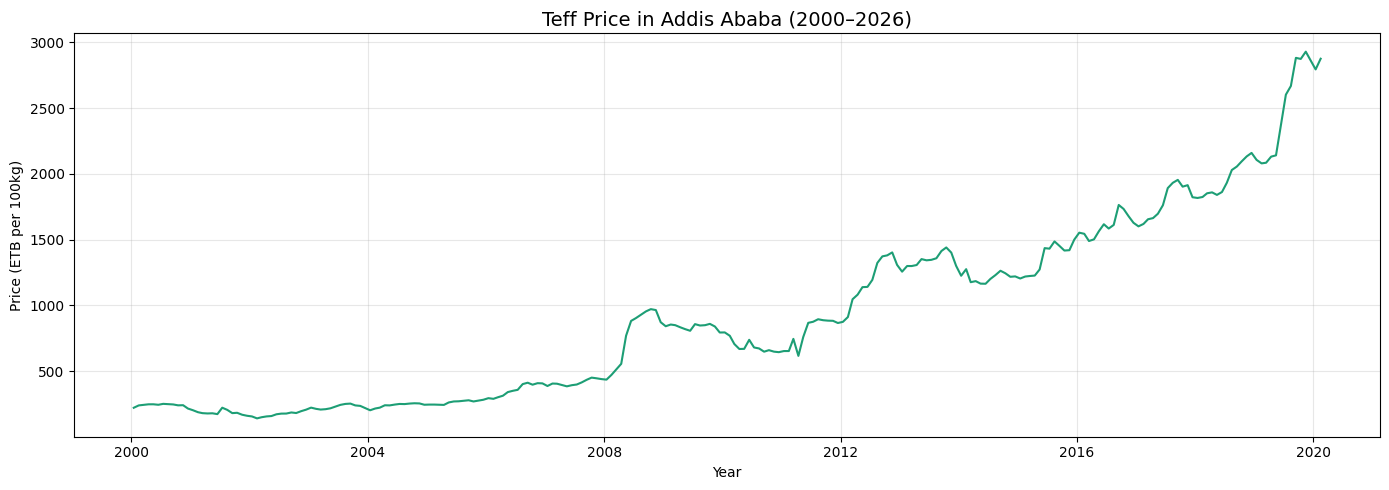

Average price: 908.02 ETB
Lowest price: 141.25 ETB
Highest price: 2930.0 ETB
Total data points: 240


In [4]:
import matplotlib.pyplot as plt

# Filter teff in Addis Ababa
teff_addis = df_clean[
    (df_clean['commodity'] == 'Teff') & 
    (df_clean['admin1'] == 'Addis Ababa')
].sort_values('date')

# Plot
plt.figure(figsize=(14, 5))
plt.plot(teff_addis['date'], teff_addis['price'], color='#1D9E75', linewidth=1.5)
plt.title('Teff Price in Addis Ababa (2000–2026)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Price (ETB per 100kg)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quick stats
print("Average price:", round(teff_addis['price'].mean(), 2), "ETB")
print("Lowest price:", round(teff_addis['price'].min(), 2), "ETB")
print("Highest price:", round(teff_addis['price'].max(), 2), "ETB")
print("Total data points:", len(teff_addis))

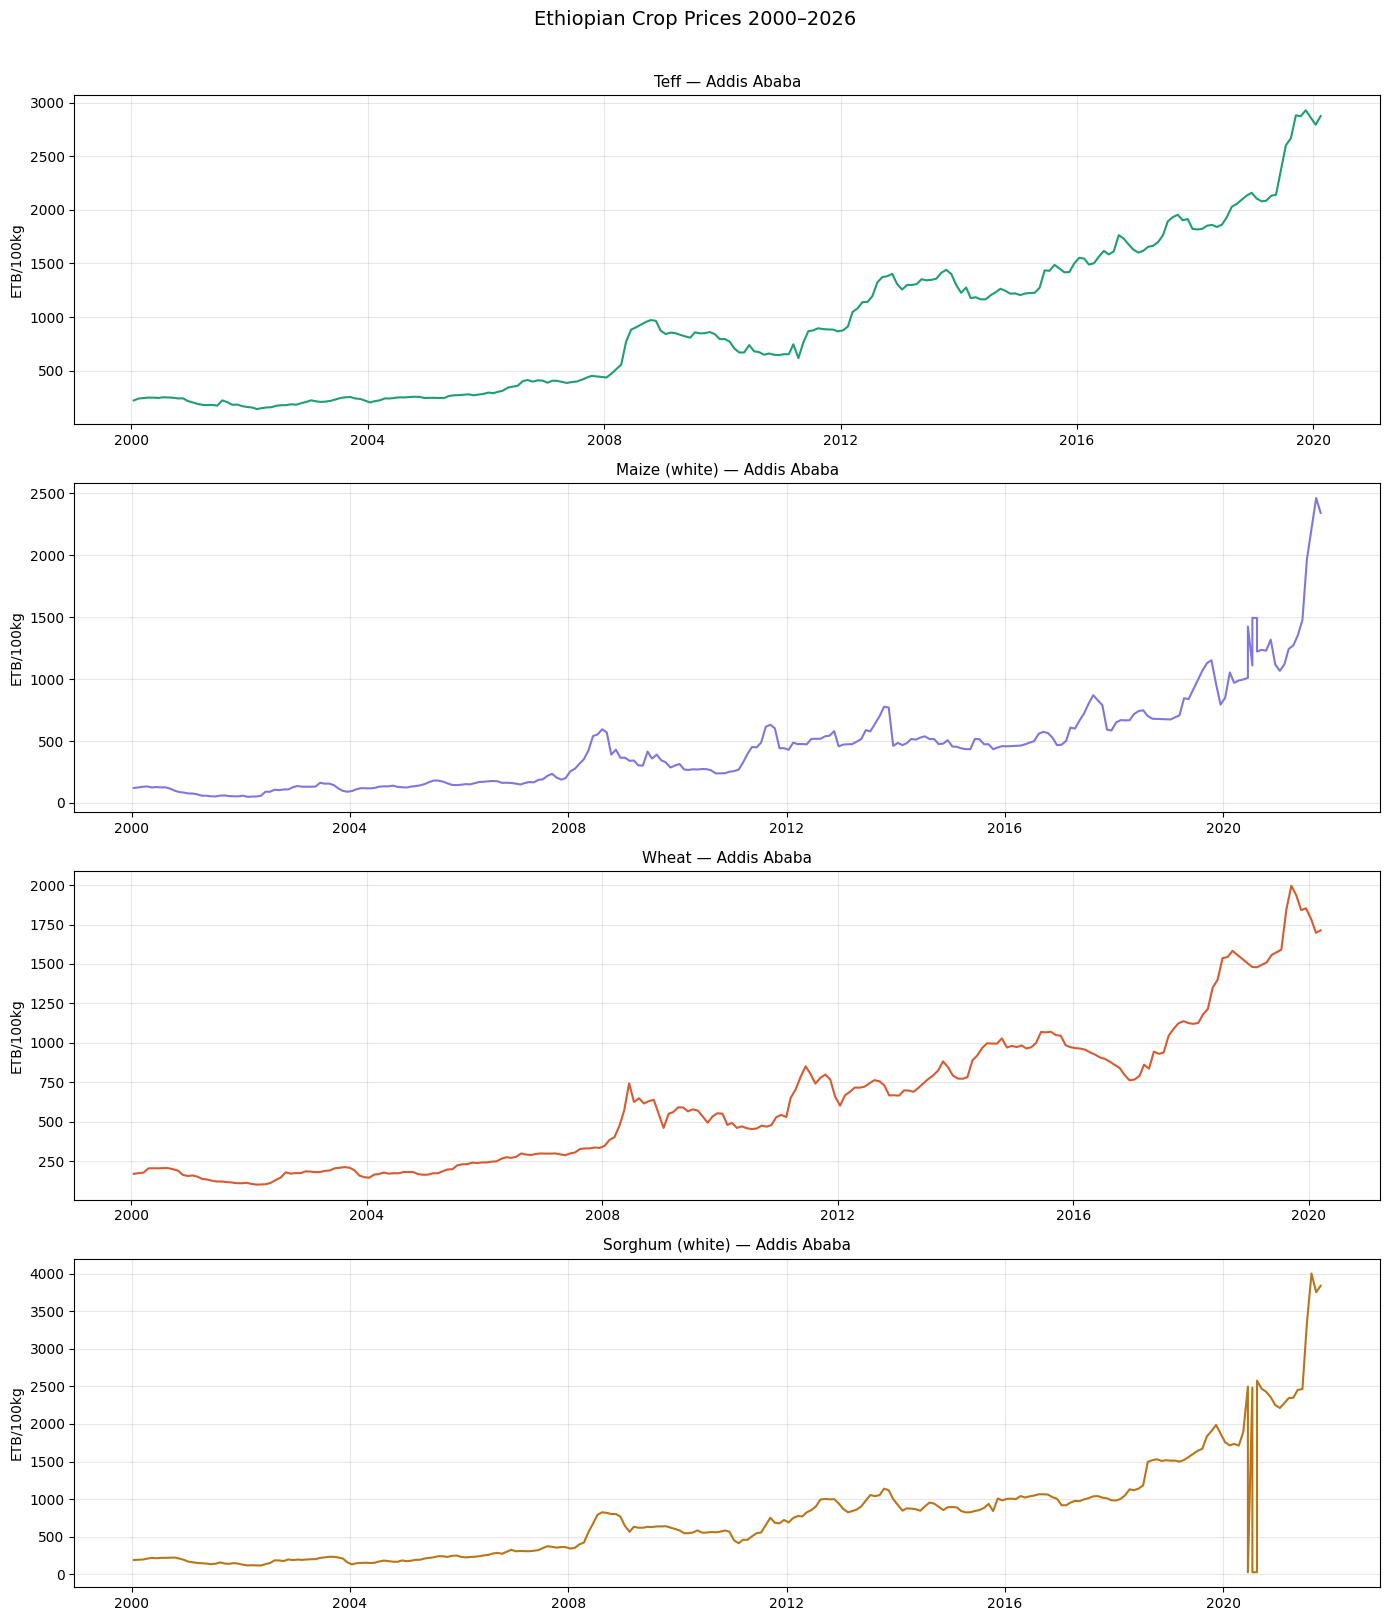

In [5]:
# All crops in Addis Ababa
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

crops = ['Teff', 'Maize (white)', 'Wheat', 'Sorghum (white)' ]
colors = ['#1D9E75', '#7F77DD', '#D85A30', '#BA7517']

for i, (crop, color) in enumerate(zip(crops, colors)):
    data = df_clean[
        (df_clean['commodity'] == crop) & 
        (df_clean['admin1'] == 'Addis Ababa')
    ].sort_values('date')
    
    axes[i].plot(data['date'], data['price'], color=color, linewidth=1.5)
    axes[i].set_title(f'{crop} — Addis Ababa', fontsize=11)
    axes[i].set_ylabel('ETB/100kg')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Ethiopian Crop Prices 2000–2026', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [6]:
# Sort data properly
df_clean = df_clean.sort_values(['commodity', 'admin1', 'date']).reset_index(drop=True)

# Lag feature — last month's price (most powerful ML feature)
df_clean['price_lag1'] = df_clean.groupby(['commodity', 'admin1'])['price'].shift(1)

# Lag 2 — price 2 months ago
df_clean['price_lag2'] = df_clean.groupby(['commodity', 'admin1'])['price'].shift(2)

# Lag 3 — price 3 months ago
df_clean['price_lag3'] = df_clean.groupby(['commodity', 'admin1'])['price'].shift(3)

# Rolling average — 3 month trend
df_clean['rolling_mean_3'] = df_clean.groupby(['commodity', 'admin1'])['price'].transform(lambda x: x.rolling(3).mean())

# Season feature
def get_season(month):
    if month in [6, 7, 8, 9]:
        return 'kiremt'      # main rainy season
    elif month in [3, 4, 5]:
        return 'belg'        # small rainy season
    elif month in [10, 11, 12]:
        return 'harvest'     # harvest time
    else:
        return 'dry'         # dry season

df_clean['season'] = df_clean['month'].apply(get_season)

# Check result
print("New columns added:")
print(df_clean.columns.tolist())
print("\nSample:")
df_clean.dropna().head(10)

New columns added:
['date', 'admin1', 'market', 'commodity', 'price', 'year', 'month', 'price_lag1', 'price_lag2', 'price_lag3', 'rolling_mean_3', 'season']

Sample:


,date,admin1,market,commodity,price,year,month,price_lag1,price_lag2,price_lag3,rolling_mean_3,season
3,2020-02-15,Afar,Abaala,Barley,1000.0,2020,2,4000.0,1000.0,4000.0,2000.000000,dry
4,2023-08-15,Afar,Abaala,Barley,9000.0,2023,8,1000.0,4000.0,1000.0,4666.666667,kiremt
8,2020-01-15,Amhara,Abomsa,Barley,1000.0,2020,1,903.0,930.0,680.0,944.333333,dry
9,2020-02-15,Amhara,Abomsa,Barley,1500.0,2020,2,1000.0,903.0,930.0,1134.333333,dry
10,2020-03-15,Amhara,Abomsa,Barley,1500.0,2020,3,1500.0,1000.0,903.0,1333.333333,belg
11,2020-04-15,Amhara,Abomsa,Barley,1300.0,2020,4,1500.0,1500.0,1000.0,1433.333333,belg
12,2020-05-15,Amhara,Abomsa,Barley,1300.0,2020,5,1300.0,1500.0,1500.0,1366.666667,belg
13,2020-06-15,Amhara,Abomsa,Barley,1350.0,2020,6,1300.0,1300.0,1500.0,1316.666667,kiremt
14,2020-07-15,Amhara,Abomsa,Barley,1400.0,2020,7,1350.0,1300.0,1300.0,1350.000000,kiremt
15,2020-08-15,Amhara,Abomsa,Barley,1400.0,2020,8,1400.0,1350.0,1300.0,1383.333333,kiremt


In [9]:
from sklearn.preprocessing import LabelEncoder

# Drop rows with NaN (from lag features)
df_ml = df_clean.dropna().copy()

# Encode categorical columns into numbers
le_commodity = LabelEncoder()
le_admin = LabelEncoder()
le_season = LabelEncoder()

df_ml['commodity_encoded'] = le_commodity.fit_transform(df_ml['commodity'])
df_ml['admin_encoded'] = le_admin.fit_transform(df_ml['admin1'])
df_ml['season_encoded'] = le_season.fit_transform(df_ml['season'])

# Define features (X) and target (y)
features = ['commodity_encoded', 'admin_encoded', 'month', 'year', 
            'price_lag1', 'price_lag2', 'price_lag3', 
            'rolling_mean_3', 'season_encoded']

X = df_ml[features]
y = df_ml['price']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature sample:")
X.head()

Features shape: (16181, 9)
Target shape: (16181,)

Feature sample:


,commodity_encoded,admin_encoded,month,year,price_lag1,price_lag2,price_lag3,rolling_mean_3,season_encoded
3,0,1,2,2020,4000.0,1000.0,4000.0,2000.000000,1
4,0,1,8,2023,1000.0,4000.0,1000.0,4666.666667,3
8,0,2,1,2020,903.0,930.0,680.0,944.333333,1
9,0,2,2,2020,1000.0,903.0,930.0,1134.333333,1
10,0,2,3,2020,1500.0,1000.0,903.0,1333.333333,0


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Split data — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Results ---")
print(f"Mean Absolute Error: {round(mae, 2)} ETB")
print(f"R² Score: {round(r2, 4)}")
print(f"\nInterpretation:")
print(f"On average the model is off by {round(mae, 2)} ETB per 100kg")
print(f"The model explains {round(r2*100, 2)}% of price variation")

Training rows: 12944
Testing rows: 3237

--- Model Results ---
Mean Absolute Error: 91.27 ETB
R² Score: 0.985

Interpretation:
On average the model is off by 91.27 ETB per 100kg
The model explains 98.5% of price variation


In [11]:
import pickle
import os

# Save the model
with open('../models/crop_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the encoders too — you need them later in the API
with open('../models/le_commodity.pkl', 'wb') as f:
    pickle.dump(le_commodity, f)

with open('../models/le_admin.pkl', 'wb') as f:
    pickle.dump(le_admin, f)

with open('../models/le_season.pkl', 'wb') as f:
    pickle.dump(le_season, f)

# Verify files saved
files = os.listdir('../models/')
print("Saved files:", files)
print("\nModel saved successfully.")
print("Your ML model is ready to be used in the API.")

Saved files: ['crop_price_model.pkl', 'le_admin.pkl', 'le_commodity.pkl', 'le_season.pkl']

Model saved successfully.
Your ML model is ready to be used in the API.
